# Standard Course Q&A RAG System

**A Retrieval-Augmented Generation system for answering student questions about university course materials.**

This notebook builds a complete, end-to-end RAG pipeline: it discovers course materials (PDF / CSV / DOCX / TXT),
extracts and cleans their text, chunks and embeds them, stores them in a persistent vector database, retrieves
relevant passages for a question, and generates a grounded, source-attributed answer with a language model.

## 1. Project Introduction

### What is RAG?

**Retrieval-Augmented Generation (RAG)** combines two components: a *retriever* that searches a knowledge base
for passages relevant to a question, and a *generator* (an LLM) that composes an answer using only those
retrieved passages. Instead of relying purely on what the language model memorized during training, the model is
given the actual source material at inference time.

### Why RAG is useful for educational systems

* Answers can be **traced back to specific lecture files and pages**, which builds trust and supports studying.
* The knowledge base can be **updated** (new lecture notes, new courses) without retraining any model.
* It naturally handles **multiple courses** by scoping retrieval to a course when needed.
* It reduces the risk of a student receiving a confident but wrong answer that has nothing to do with what was
  actually taught.

### Traditional LLM vs. RAG

| | Traditional LLM | RAG |
|---|---|---|
| Knowledge source | Frozen training data | Retrieved course documents, at query time |
| Freshness | Fixed at training time | Always reflects the current uploaded materials |
| Traceability | None — answers are not attributable | Every answer cites its source chunks |
| Hallucination risk | Higher — the model may "fill in" facts | Lower — the model is instructed to answer only from context |

### How retrieval reduces hallucination

By construction, the LLM in this system is instructed (via the RAG prompt in Section 16) to answer **only** from
the text chunks retrieved for the question, and to explicitly say when the answer is not present in the retrieved
material. Combined with grounding the context in real, retrieved chunks — rather than the model's parametric
memory — this significantly reduces fabricated answers, and the system exposes exactly which sources were used so
answers can be checked.

### End-to-end architecture

```
 User Question
      |
      v
 Query Embedding
      |
      v
 Vector Database  <---  Embedded Course Chunks  <---  Chunking  <---  Cleaning  <---  Document Loaders  <---  Course Files (PDF/CSV/DOCX/TXT)
      |
      v
 Retriever (top-k, similarity, optional course filter)
      |
      v
 Relevant Course Chunks
      |
      v
 Prompt Construction (strict grounding rules)
      |
      v
 LLM  (local HF model, or an external API)
      |
      v
 Grounded Answer + Source Attribution
```

### Component glossary

* **Document Loader** — extracts raw text (and page/row metadata) from PDF, CSV, DOCX and TXT files.
* **Text Splitter** — breaks long documents into overlapping chunks small enough to embed and retrieve precisely.
* **Embedding Model** — a sentence-transformer that maps text to a dense vector capturing its meaning.
* **Vector Database** — stores chunk vectors + metadata and supports fast approximate nearest-neighbour search
  (here: ChromaDB, persisted to disk).
* **Retriever** — turns a question into a query vector and returns the most similar chunks, optionally filtered
  by course.
* **LLM** — generates the final answer from the retrieved context; the backend is swappable (local model or API).
* **Prompt Template** — the strict instructions that force the LLM to stay grounded in the retrieved context.
* **Source Attribution** — maps every answer back to the exact course / file / page it came from.

## 2. Architecture Overview

This notebook is organized so that every stage of the pipeline is a small, testable, reusable Python function
rather than inline scratch code. That means:

* `load_document()` is the single entry point for turning *any* supported file into raw text + metadata.
* `clean_text()`, `recursive_character_split()`, and `embedding_model.encode()` are pure functions with no side
  effects — they can be unit-tested independently.
* `retrieve_documents()`, `build_prompt()` and `generate_answer()` are composed into a single
  `answer_question()` pipeline function, which is the *only* function `app.py` needs to reimplement to serve the
  same behaviour through Gradio.
* All persisted artifacts (vector DB + `config.json`) live under `/kaggle/working/`, which is exactly what Kaggle
  keeps available for download after the notebook finishes running — this is the hand-off point to `app.py`.

## 3. Environment Setup


In [1]:
!pip install -q -U sentence-transformers chromadb pypdf python-docx sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204

In [2]:
import os
import re
import sys
import json
import time
import random
import unicodedata
import platform
import warnings
from pathlib import Path
from typing import List, Dict, Optional, Any

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
else:
    print("GPU            : none detected - running on CPU")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Python version : 3.12.13
PyTorch version: 2.10.0+cu128
CUDA available : True
GPU            : Tesla T4


## 4. Global Configuration


In [3]:
CONFIG = {
    "SEED": 42,

    "CHUNK_SIZE": 500,
    "CHUNK_OVERLAP": 100,

    "TOP_K": 5,
    "SIMILARITY_THRESHOLD": 0.0,

    "EMBEDDING_MODEL": "sentence-transformers/all-MiniLM-L6-v2",

    "LLM_BACKEND": os.environ.get("RAG_LLM_BACKEND", "local"),
    "LOCAL_LLM_MODEL": "google/flan-t5-base",
    "API_MODEL_NAME": os.environ.get("RAG_API_MODEL", "gpt-4o-mini"),

    "INPUT_DIR": "/kaggle/input",
    "WORKING_DIR": "/kaggle/working",
    "VECTOR_DB_PATH": "/kaggle/working/vector_db",
    "OUTPUT_DIR": "/kaggle/working/rag_outputs",
    "COLLECTION_NAME": "course_qa_collection",

    "COURSES": ["Machine Learning", "Database Systems", "Computer Networks"],
}

Path(CONFIG["VECTOR_DB_PATH"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

PERF: Dict[str, float] = {}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  SEED: 42
  CHUNK_SIZE: 500
  CHUNK_OVERLAP: 100
  TOP_K: 5
  SIMILARITY_THRESHOLD: 0.0
  EMBEDDING_MODEL: sentence-transformers/all-MiniLM-L6-v2
  LLM_BACKEND: local
  LOCAL_LLM_MODEL: google/flan-t5-base
  API_MODEL_NAME: gpt-4o-mini
  INPUT_DIR: /kaggle/input
  WORKING_DIR: /kaggle/working
  VECTOR_DB_PATH: /kaggle/working/vector_db
  OUTPUT_DIR: /kaggle/working/rag_outputs
  COLLECTION_NAME: course_qa_collection
  COURSES: ['Machine Learning', 'Database Systems', 'Computer Networks']


## 5. Reproducibility


In [4]:
def set_seed(seed: int = CONFIG["SEED"]) -> None:
    """Seed all relevant random number generators for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Seed set to {CONFIG['SEED']}")

Seed set to 42


## 6. Dataset Discovery

We recursively scan `/kaggle/input/` for any `.pdf`, `.csv`, `.docx` or `.txt` file — **no filename is
hard-coded**. For each file we try to infer which course it belongs to from its parent folder name or the
filename itself, using a small keyword table for the three demo courses (Machine Learning, Database Systems,
Computer Networks). Files that don't match a known keyword fall back to their parent folder name, or
`Course_1`, `Course_2`, ... if nothing informative is available.

In [5]:
SUPPORTED_EXTENSIONS = {".pdf", ".csv", ".docx", ".txt"}

COURSE_KEYWORDS = {
    "Machine Learning": ["machine learning", "machinelearning", "ml_", "_ml", "ml-", " ml "],
    "Database Systems": ["database", "dbms", "sql", "db_", "_db", "-db"],
    "Computer Networks": ["network", "networking", "tcp", "-net", "_net"],
}


def detect_course_from_path(file_path: Path) -> str:
    """Infer a course name from the parent folder name(s) or the filename."""
    haystack = " ".join([p.name for p in list(file_path.parents)[:2]] + [file_path.stem]).lower()
    for course, keywords in COURSE_KEYWORDS.items():
        if any(k in haystack for k in keywords):
            return course
    parent_name = file_path.parent.name
    if parent_name and parent_name.lower() not in ("input", "kaggle", ""):
        return parent_name
    return "Unknown"


def discover_files(root: str) -> pd.DataFrame:
    """Recursively discover all supported course-material files under `root`."""
    root_path = Path(root)
    records = []
    if root_path.exists():
        for file_path in root_path.rglob("*"):
            if file_path.is_file() and file_path.suffix.lower() in SUPPORTED_EXTENSIONS:
                records.append({
                    "file_name": file_path.name,
                    "file_path": str(file_path),
                    "extension": file_path.suffix.lower(),
                    "detected_course": detect_course_from_path(file_path),
                })
    return pd.DataFrame(records, columns=["file_name", "file_path", "extension", "detected_course"])


dataset_df = discover_files(CONFIG["INPUT_DIR"])
print(f"Discovered {len(dataset_df)} candidate file(s) under {CONFIG['INPUT_DIR']}")
dataset_df.head(20)

Discovered 0 candidate file(s) under /kaggle/input


,file_name,file_path,extension,detected_course


## 7. Demo Dataset Fallback


In [6]:
DEMO_DATA_DIR = Path(CONFIG["WORKING_DIR"]) / "demo_course_materials"

DEMO_CONTENT = {
    "Machine Learning": {
        "notes": [
            "Supervised learning trains a model on labeled examples, learning a mapping from inputs to known "
            "outputs so it can predict labels for new, unseen inputs. Common tasks include classification "
            "(predicting a category) and regression (predicting a continuous value).",
            "Overfitting occurs when a model learns the noise and specific quirks of the training data instead "
            "of the underlying pattern. An overfit model shows very low training error but much higher error on "
            "validation or test data. Common remedies include regularization, more training data, simpler "
            "models, dropout, and early stopping.",
            "Cross-validation estimates how well a model generalizes by repeatedly splitting the data into "
            "training and validation folds. In k-fold cross-validation, the data is split into k parts; the "
            "model is trained on k-1 parts and validated on the remaining part, and this is repeated k times so "
            "every example is used for validation exactly once.",
            "A confusion matrix summarizes classification performance by tabulating true positives, true "
            "negatives, false positives, and false negatives. From it we derive precision (how many predicted "
            "positives were correct), recall (how many actual positives were found), and the F1 score, which is "
            "the harmonic mean of precision and recall.",
        ],
        "csv_rows": [
            {"term": "Gradient Descent", "definition": "An iterative optimization algorithm that updates model "
             "parameters in the direction that most reduces the loss function."},
            {"term": "Regularization", "definition": "A technique (e.g. L1/L2 penalties, dropout) that "
             "discourages overly complex models to reduce overfitting."},
            {"term": "Feature Scaling", "definition": "Rescaling input features, e.g. via standardization or "
             "min-max normalization, so that no single feature dominates the learning process."},
            {"term": "Bias-Variance Tradeoff", "definition": "The tension between a model being too simple "
             "(high bias, underfitting) and too complex (high variance, overfitting)."},
        ],
        "pdf_pages": [
            "Lecture 3: Neural Networks\n\nA neural network is composed of layers of interconnected units "
            "(neurons). Each connection has a weight, and each neuron applies an activation function (such as "
            "ReLU or sigmoid) to the weighted sum of its inputs. Stacking multiple layers allows the network to "
            "learn increasingly abstract representations of the input data.",
            "Backpropagation is the algorithm used to train neural networks. It computes the gradient of the "
            "loss function with respect to every weight in the network by applying the chain rule backward from "
            "the output layer to the input layer, then updates the weights using gradient descent.",
        ],
    },
    "Database Systems": {
        "notes": [
            "Database normalization is the process of organizing tables to reduce data redundancy and avoid "
            "update, insert, and delete anomalies. It is achieved by decomposing tables according to a series "
            "of normal forms.",
            "First Normal Form (1NF) requires that every column contain atomic (indivisible) values and that "
            "each record be unique. Second Normal Form (2NF) requires 1NF plus the removal of partial "
            "dependencies on a composite primary key. Third Normal Form (3NF) requires 2NF plus the removal of "
            "transitive dependencies, so non-key columns depend only on the primary key.",
            "A transaction is a sequence of database operations executed as a single logical unit of work. The "
            "ACID properties guarantee that transactions are Atomic (all-or-nothing), Consistent (valid state to "
            "valid state), Isolated (concurrent transactions do not interfere), and Durable (committed changes "
            "survive failures).",
            "An index is an auxiliary data structure, commonly a B-tree, that speeds up row lookups on a table "
            "at the cost of extra storage and slower writes, since the index must also be updated whenever the "
            "underlying data changes.",
        ],
        "csv_rows": [
            {"term": "Primary Key", "definition": "A column or set of columns that uniquely identifies each row "
             "in a table."},
            {"term": "Foreign Key", "definition": "A column that references the primary key of another table, "
             "enforcing referential integrity between the two tables."},
            {"term": "Join", "definition": "A SQL operation that combines rows from two or more tables based on "
             "a related column between them."},
            {"term": "Deadlock", "definition": "A state where two or more transactions are each waiting for a "
             "lock held by the other, so none of them can proceed."},
        ],
        "pdf_pages": [
            "Lecture 4: Query Optimization\n\nA query optimizer chooses an efficient execution plan for a SQL "
            "query by estimating the cost of alternative plans (e.g. different join orders or access paths) "
            "using statistics about table sizes and data distributions, then picks the plan with the lowest "
            "estimated cost.",
            "Concurrency control ensures that transactions running at the same time do not violate the "
            "isolation property. Common techniques include two-phase locking, which acquires all locks before "
            "releasing any, and multiversion concurrency control (MVCC), which lets readers see a consistent "
            "snapshot without blocking writers.",
        ],
    },
    "Computer Networks": {
        "notes": [
            "TCP (Transmission Control Protocol) is a connection-oriented, reliable transport-layer protocol. "
            "Before data is exchanged, TCP performs a three-way handshake (SYN, SYN-ACK, ACK) to establish a "
            "connection, and it guarantees ordered, error-checked delivery of a stream of bytes between "
            "applications.",
            "TCP congestion control regulates how fast a sender transmits data to avoid overwhelming the "
            "network. Slow start increases the congestion window exponentially until a threshold is reached, "
            "after which congestion avoidance increases it linearly; on packet loss, the window is reduced "
            "(e.g. halved, as in TCP Reno) and the process resumes more cautiously.",
            "The OSI model describes networking in seven layers: Physical, Data Link, Network, Transport, "
            "Session, Presentation, and Application. Each layer provides services to the layer above it and "
            "relies on services from the layer below it.",
            "DNS (Domain Name System) translates human-readable domain names into IP addresses. It is a "
            "distributed, hierarchical system: a resolver queries root servers, then top-level-domain servers, "
            "then authoritative name servers, caching results along the way to reduce future lookup latency.",
        ],
        "csv_rows": [
            {"term": "IP Address", "definition": "A numerical label assigned to each device on a network that "
             "identifies it and allows it to be located by other devices."},
            {"term": "Router", "definition": "A network device that forwards data packets between different "
             "networks based on their destination IP address."},
            {"term": "Latency", "definition": "The time it takes for a packet of data to travel from its source "
             "to its destination across a network."},
            {"term": "Firewall", "definition": "A network security system that monitors and controls incoming "
             "and outgoing traffic based on a defined set of rules."},
        ],
        "pdf_pages": [
            "Lecture 2: The Application Layer\n\nHTTP is an application-layer protocol used for transferring "
            "web content. It is a request-response protocol: a client sends a request (e.g. GET, POST) to a "
            "server, and the server replies with a status code and, typically, a body containing the requested "
            "resource.",
            "UDP (User Datagram Protocol) is a connectionless transport-layer protocol that sends datagrams "
            "without establishing a connection or guaranteeing delivery, ordering, or error recovery. Its lower "
            "overhead makes it suitable for latency-sensitive applications like live video and DNS lookups.",
        ],
    },
}


def _write_demo_txt(course_dir: Path, course: str) -> None:
    content = "\n\n".join(DEMO_CONTENT[course]["notes"])
    (course_dir / f"{course.replace(' ', '_').lower()}_notes.txt").write_text(content, encoding="utf-8")


def _write_demo_csv(course_dir: Path, course: str) -> None:
    df = pd.DataFrame(DEMO_CONTENT[course]["csv_rows"])
    df.to_csv(course_dir / f"{course.replace(' ', '_').lower()}_glossary.csv", index=False)


def _write_demo_docx(course_dir: Path, course: str) -> None:
    import docx
    document = docx.Document()
    document.add_heading(f"{course} - Lecture Notes", level=1)
    for paragraph in DEMO_CONTENT[course]["notes"]:
        document.add_paragraph(paragraph)
    table = document.add_table(rows=1, cols=2)
    table.rows[0].cells[0].text = "Term"
    table.rows[0].cells[1].text = "Definition"
    for row in DEMO_CONTENT[course]["csv_rows"]:
        cells = table.add_row().cells
        cells[0].text = row["term"]
        cells[1].text = row["definition"]
    document.save(course_dir / f"{course.replace(' ', '_').lower()}_lecture.docx")


def _write_demo_pdf(course_dir: Path, course: str) -> None:
    from matplotlib.backends.backend_pdf import PdfPages
    import textwrap
    pdf_path = course_dir / f"{course.replace(' ', '_').lower()}_slides.pdf"
    with PdfPages(pdf_path) as pdf:
        for page_text in DEMO_CONTENT[course]["pdf_pages"]:
            fig, ax = plt.subplots(figsize=(8.27, 11.69))  # A4
            ax.axis("off")
            wrapped = "\n".join(textwrap.fill(line, 90) for line in page_text.split("\n"))
            ax.text(0.05, 0.95, wrapped, transform=ax.transAxes, fontsize=11,
                     verticalalignment="top", family="monospace")
            pdf.savefig(fig)
            plt.close(fig)


def create_demo_dataset(base_dir: Path) -> None:
    """Programmatically generate a small demo course-materials dataset."""
    for course in CONFIG["COURSES"]:
        course_dir = base_dir / course
        course_dir.mkdir(parents=True, exist_ok=True)
        _write_demo_txt(course_dir, course)
        _write_demo_csv(course_dir, course)
        _write_demo_docx(course_dir, course)
        _write_demo_pdf(course_dir, course)


USING_DEMO_DATA = dataset_df.empty

if USING_DEMO_DATA:
    print("No real course materials found under /kaggle/input/ - generating a DEMO dataset as a fallback.")
    create_demo_dataset(DEMO_DATA_DIR)
    dataset_df = discover_files(str(DEMO_DATA_DIR))
    print(f"Demo dataset created: {len(dataset_df)} files under {DEMO_DATA_DIR}")
else:
    print(f"Using REAL course materials found under {CONFIG['INPUT_DIR']} - demo dataset was NOT generated.")

unknown_mask = dataset_df["detected_course"] == "Unknown"
if unknown_mask.any():
    unknown_names = sorted(dataset_df.loc[unknown_mask, "file_path"].apply(lambda p: Path(p).parent.name).unique())
    rename_map = {name: f"Course_{i + 1}" for i, name in enumerate(unknown_names)}
    dataset_df.loc[unknown_mask, "detected_course"] = dataset_df.loc[unknown_mask, "file_path"].apply(
        lambda p: rename_map.get(Path(p).parent.name, "Course_1")
    )

course_counts = dataset_df["detected_course"].value_counts()
print("\nFiles per course:")
print(course_counts.to_string())

DETECTED_COURSES = sorted(dataset_df["detected_course"].unique().tolist())
dataset_df.head(20)

No real course materials found under /kaggle/input/ - generating a DEMO dataset as a fallback.
Demo dataset created: 12 files under /kaggle/working/demo_course_materials

Files per course:
detected_course
Database Systems     4
Computer Networks    4
Machine Learning     4


,file_name,file_path,extension,detected_course
0,database_systems_glossary.csv,/kaggle/working/demo_course_materials/Database...,.csv,Database Systems
1,database_systems_lecture.docx,/kaggle/working/demo_course_materials/Database...,.docx,Database Systems
2,database_systems_notes.txt,/kaggle/working/demo_course_materials/Database...,.txt,Database Systems
3,database_systems_slides.pdf,/kaggle/working/demo_course_materials/Database...,.pdf,Database Systems
4,computer_networks_slides.pdf,/kaggle/working/demo_course_materials/Computer...,.pdf,Computer Networks
5,computer_networks_notes.txt,/kaggle/working/demo_course_materials/Computer...,.txt,Computer Networks
6,computer_networks_glossary.csv,/kaggle/working/demo_course_materials/Computer...,.csv,Computer Networks
7,computer_networks_lecture.docx,/kaggle/working/demo_course_materials/Computer...,.docx,Computer Networks
8,machine_learning_lecture.docx,/kaggle/working/demo_course_materials/Machine ...,.docx,Machine Learning
9,machine_learning_notes.txt,/kaggle/working/demo_course_materials/Machine ...,.txt,Machine Learning


## 8. Document Loading

Each supported file type has its own robust loader function, unified behind a single `load_document()` entry
point that always returns a list of `{"text": ..., "metadata": {...}}` records:

* **PDF** — extracted page by page (via `pypdf`), preserving the page number in metadata.
* **CSV** — each row is converted into a readable `"column: value"` sentence rather than a raw DataFrame dump,
  preserving column names.
* **DOCX** — paragraph text and table content (converted into readable pipe-separated rows) are both extracted.
* **TXT** — read with an encoding fallback chain (`utf-8` → `utf-8-sig` → `latin-1`).

All loaders catch and report errors for corrupted or unreadable files instead of crashing the pipeline.

In [7]:
from pypdf import PdfReader
import docx as docx_lib


def load_pdf(path: str) -> List[Dict[str, Any]]:
    """Extract text page-by-page from a PDF, preserving page numbers."""
    records = []
    try:
        reader = PdfReader(path)
        for i, page in enumerate(reader.pages):
            text = (page.extract_text() or "").strip()
            if text:
                records.append({"text": text, "page": i + 1})
    except Exception as exc:
        print(f"[WARN] Failed to read PDF '{path}': {exc}")
    return records


def load_csv(path: str) -> List[Dict[str, Any]]:
    """Convert each CSV row into a readable sentence, preserving column names."""
    records = []
    try:
        df = pd.read_csv(path)
        for idx, row in df.iterrows():
            parts = [f"{col}: {row[col]}" for col in df.columns if pd.notna(row[col])]
            text = ". ".join(parts)
            if text.strip():
                records.append({"text": text, "page": None, "row": int(idx)})
    except Exception as exc:
        print(f"[WARN] Failed to read CSV '{path}': {exc}")
    return records


def load_docx(path: str) -> List[Dict[str, Any]]:
    """Extract paragraph text and table content from a DOCX file."""
    records = []
    try:
        document = docx_lib.Document(path)
        paragraphs = [p.text for p in document.paragraphs if p.text.strip()]
        full_text = "\n".join(paragraphs)
        if full_text.strip():
            records.append({"text": full_text, "page": None})
        for t_idx, table in enumerate(document.tables):
            rows_text = [" | ".join(cell.text.strip() for cell in row.cells) for row in table.rows]
            table_text = "\n".join(r for r in rows_text if r.strip())
            if table_text.strip():
                records.append({"text": f"[Table {t_idx + 1}]\n{table_text}", "page": None})
    except Exception as exc:
        print(f"[WARN] Failed to read DOCX '{path}': {exc}")
    return records


def load_txt(path: str) -> List[Dict[str, Any]]:
    """Read a TXT file, falling back across encodings if needed."""
    records = []
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            text = Path(path).read_text(encoding=encoding)
            if text.strip():
                records.append({"text": text, "page": None})
            break
        except (UnicodeDecodeError, LookupError):
            continue
        except Exception as exc:
            print(f"[WARN] Failed to read TXT '{path}': {exc}")
            break
    return records


LOADERS = {".pdf": load_pdf, ".csv": load_csv, ".docx": load_docx, ".txt": load_txt}


def load_document(file_path: str, course: str, file_type: str) -> List[Dict[str, Any]]:
    """Unified loader: dispatches to the right format-specific loader and attaches metadata."""
    loader = LOADERS.get(file_type)
    if loader is None:
        print(f"[WARN] Unsupported file type '{file_type}' for '{file_path}' - skipping.")
        return []
    raw_records = loader(file_path)
    documents = []
    for rec in raw_records:
        documents.append({
            "text": rec["text"],
            "metadata": {
                "source": Path(file_path).name,
                "file_name": Path(file_path).name,
                "file_type": file_type,
                "course": course,
                "page": rec.get("page"),
            },
        })
    return documents


_t0 = time.perf_counter()
raw_documents: List[Dict[str, Any]] = []
for _, row in dataset_df.iterrows():
    raw_documents.extend(load_document(row["file_path"], row["detected_course"], row["extension"]))
PERF["document_loading_sec"] = time.perf_counter() - _t0

print(f"Loaded {len(raw_documents)} raw text segment(s) from {len(dataset_df)} file(s) "
      f"in {PERF['document_loading_sec']:.2f}s")

Loaded 27 raw text segment(s) from 12 file(s) in 0.07s


## 9. Text Cleaning


In [8]:
def clean_text(text: str) -> str:
    """Normalize whitespace/Unicode and remove common extraction artifacts, without losing information."""
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\x0c", "\n")              
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"-\n(?=[a-z])", "", text)         
    text = re.sub(r"[ \t]+", " ", text)              
    text = re.sub(r"\n{3,}", "\n\n", text)           
    text = re.sub(r"(?m)^[ \t]+|[ \t]+$", "", text)  
    return text.strip()


if raw_documents:
    sample_before = raw_documents[0]["text"][:350]
    sample_after = clean_text(sample_before)
    print("BEFORE:\n" + repr(sample_before[:350]))
    print("\nAFTER:\n" + repr(sample_after[:350]))

for doc in raw_documents:
    doc["text"] = clean_text(doc["text"])

before_count = len(raw_documents)
raw_documents = [d for d in raw_documents if d["text"]]
print(f"\n{len(raw_documents)}/{before_count} documents remain non-empty after cleaning")

BEFORE:
'term: Primary Key. definition: A column or set of columns that uniquely identifies each row in a table.'

AFTER:
'term: Primary Key. definition: A column or set of columns that uniquely identifies each row in a table.'

27/27 documents remain non-empty after cleaning


## 10. Document Metadata


In [9]:
for i, doc in enumerate(raw_documents):
    doc["metadata"]["doc_id"] = i

pd.DataFrame([d["metadata"] for d in raw_documents]).head(10)

,source,file_name,file_type,course,page,doc_id
0,database_systems_glossary.csv,database_systems_glossary.csv,.csv,Database Systems,NaN,0
1,database_systems_glossary.csv,database_systems_glossary.csv,.csv,Database Systems,NaN,1
2,database_systems_glossary.csv,database_systems_glossary.csv,.csv,Database Systems,NaN,2
3,database_systems_glossary.csv,database_systems_glossary.csv,.csv,Database Systems,NaN,3
4,database_systems_lecture.docx,database_systems_lecture.docx,.docx,Database Systems,NaN,4
5,database_systems_lecture.docx,database_systems_lecture.docx,.docx,Database Systems,NaN,5
6,database_systems_notes.txt,database_systems_notes.txt,.txt,Database Systems,NaN,6
7,database_systems_slides.pdf,database_systems_slides.pdf,.pdf,Database Systems,1.0,7
8,database_systems_slides.pdf,database_systems_slides.pdf,.pdf,Database Systems,2.0,8
9,computer_networks_slides.pdf,computer_networks_slides.pdf,.pdf,Computer Networks,1.0,9


## 11. Text Chunking

Long documents must be split into smaller passages before embedding, for two reasons: embedding models have a
limited effective context window (quality degrades on very long inputs), and retrieval precision improves when
each stored unit covers one focused idea rather than an entire lecture. We implement a dependency-free
`recursive_character_split()` that mirrors the strategy popularized by LangChain's
`RecursiveCharacterTextSplitter`: it tries to split on paragraph breaks first, then sentence breaks, then spaces,
falling back to hard character slicing only as a last resort - which keeps chunks from splitting a sentence in
the middle whenever possible. A configurable overlap keeps a little context from the end of one chunk at the
start of the next, so information near a boundary isn't lost.

In [10]:
def recursive_character_split(text: str, chunk_size: int, chunk_overlap: int,
                               separators: Optional[List[str]] = None) -> List[str]:
    """Dependency-free reimplementation of recursive character-based text splitting."""
    if separators is None:
        separators = ["\n\n", "\n", ". ", " ", ""]

    def _split(chunk_text: str, seps: List[str]) -> List[str]:
        if len(chunk_text) <= chunk_size:
            return [chunk_text] if chunk_text else []
        if not seps:
            return [chunk_text[i:i + chunk_size] for i in range(0, len(chunk_text), chunk_size)]
        sep, remaining = seps[0], seps[1:]
        parts = chunk_text.split(sep) if sep else list(chunk_text)
        pieces, buffer = [], ""
        for part in parts:
            candidate = buffer + (sep if buffer else "") + part
            if len(candidate) <= chunk_size:
                buffer = candidate
            else:
                if buffer:
                    pieces.append(buffer)
                if len(part) > chunk_size:
                    pieces.extend(_split(part, remaining))
                    buffer = ""
                else:
                    buffer = part
        if buffer:
            pieces.append(buffer)
        return pieces

    pieces = _split(text, separators)
    if chunk_overlap > 0 and len(pieces) > 1:
        overlapped = [pieces[0]]
        for piece in pieces[1:]:
            prev_tail = overlapped[-1][-chunk_overlap:]
            overlapped.append((prev_tail + piece)[:chunk_size + chunk_overlap])
        return overlapped
    return pieces


_t0 = time.perf_counter()
chunks: List[Dict[str, Any]] = []
_global_chunk_counter = 0  
for doc in raw_documents:
    pieces = recursive_character_split(doc["text"], CONFIG["CHUNK_SIZE"], CONFIG["CHUNK_OVERLAP"])
    for piece in pieces:
        meta = dict(doc["metadata"])
        course_tag = meta["course"].replace(" ", "")[:12]
        file_tag = Path(meta["file_name"]).stem
        page_tag = meta.get("page") if meta.get("page") is not None else "NA"
        meta["chunk_id"] = f"{course_tag}_{file_tag}_{page_tag}_{_global_chunk_counter:04d}"
        chunks.append({"text": piece, "metadata": meta})
        _global_chunk_counter += 1
PERF["chunking_sec"] = time.perf_counter() - _t0

chunk_lengths = [len(c["text"]) for c in chunks]
print(f"Documents: {len(raw_documents)} | Chunks: {len(chunks)} | Chunking time: {PERF['chunking_sec']:.2f}s")
print(f"Avg chunk length: {np.mean(chunk_lengths):.1f} chars | "
      f"Min: {min(chunk_lengths)} | Max: {max(chunk_lengths)}")

Documents: 27 | Chunks: 47 | Chunking time: 0.00s
Avg chunk length: 302.7 chars | Min: 103 | Max: 475


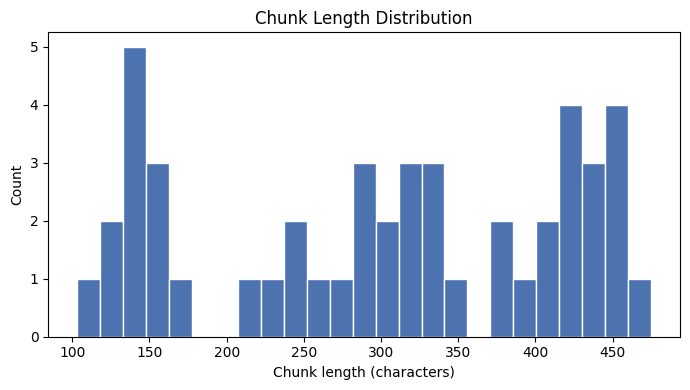

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(chunk_lengths, bins=25, color="#4C72B0", edgecolor="white")
ax.set_title("Chunk Length Distribution")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 12. Embedding Model

An **embedding** maps a piece of text to a dense numerical vector such that semantically similar texts end up
close together in vector space. This is what lets **semantic search** find a chunk about "model memorizing
training noise" as relevant to the query "what is overfitting?", even without any shared keywords - unlike
**keyword search** (e.g. TF-IDF or BM25), which only matches on literal term overlap and would miss that
connection.

We use `sentence-transformers/all-MiniLM-L6-v2`: small (~80MB), fast on CPU, and a strong general-purpose choice
for semantic search - a good fit for Kaggle's resource limits.

In [12]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(CONFIG["EMBEDDING_MODEL"], device=DEVICE)

chunk_texts = [c["text"] for c in chunks]

_t0 = time.perf_counter()
chunk_embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
) if chunk_texts else np.zeros((0, 384), dtype=np.float32)
PERF["embedding_generation_sec"] = time.perf_counter() - _t0

print(f"Embedded {len(chunk_texts)} chunks in {PERF['embedding_generation_sec']:.2f}s")
print(f"Embedding dimensionality: {chunk_embeddings.shape[1] if len(chunk_embeddings) else 'N/A'}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedded 47 chunks in 0.67s
Embedding dimensionality: 384


## 13. Vector Database

Chunk embeddings, text, and metadata are stored in a **persistent ChromaDB collection** on disk at
`CONFIG["VECTOR_DB_PATH"]`. If the collection already contains data (e.g. on a notebook rerun), we skip
re-embedding and re-indexing entirely. This same on-disk database is what `app.py` loads directly - it is the
hand-off artifact between the notebook and the deployed app.

In [13]:
import chromadb

chroma_client = chromadb.PersistentClient(path=CONFIG["VECTOR_DB_PATH"])
collection = chroma_client.get_or_create_collection(
    name=CONFIG["COLLECTION_NAME"],
    metadata={"hnsw:space": "cosine"},
)

_t0 = time.perf_counter()
if collection.count() == 0 and chunks:
    ids = [c["metadata"]["chunk_id"] for c in chunks]
    metadatas = [{k: ("" if v is None else v) for k, v in c["metadata"].items()} for c in chunks]
    BATCH = 512
    for start in range(0, len(ids), BATCH):
        end = start + BATCH
        collection.add(
            ids=ids[start:end],
            embeddings=chunk_embeddings[start:end].tolist(),
            documents=chunk_texts[start:end],
            metadatas=metadatas[start:end],
        )
    print(f"Indexed {collection.count()} chunks into ChromaDB collection '{CONFIG['COLLECTION_NAME']}'")
else:
    print(f"Vector DB already contains {collection.count()} chunks - skipping re-indexing")
PERF["vector_db_build_sec"] = time.perf_counter() - _t0

Indexed 47 chunks into ChromaDB collection 'course_qa_collection'


## 14. Retriever


In [14]:
def retrieve_documents(query: str, top_k: int = CONFIG["TOP_K"], course: Optional[str] = None,
                        similarity_threshold: float = CONFIG["SIMILARITY_THRESHOLD"]) -> List[Dict[str, Any]]:
    """Embed `query` and return the top_k most similar chunks, optionally scoped to one course."""
    if not query or not query.strip() or collection.count() == 0:
        return []
    query_embedding = embedding_model.encode([query], normalize_embeddings=True)[0].tolist()
    where_filter = {"course": course} if course and course != "All Courses" else None
    results = collection.query(query_embeddings=[query_embedding], n_results=top_k, where=where_filter)

    retrieved = []
    if results["ids"] and results["ids"][0]:
        for i in range(len(results["ids"][0])):
            similarity = 1 - results["distances"][0][i]
            if similarity >= similarity_threshold:
                retrieved.append({
                    "text": results["documents"][0][i],
                    "metadata": results["metadatas"][0][i],
                    "similarity": round(float(similarity), 4),
                })
    return retrieved


print("retrieve_documents() ready.")

retrieve_documents() ready.


## 15. Retrieval Visualization

A quick sanity check: retrieve the top matches for a sample question and inspect the ranked results.

In [15]:
sample_query = "What is overfitting?"
sample_results = retrieve_documents(sample_query, top_k=5)

print(f"Question: {sample_query!r}\n")
pd.DataFrame([{
    "Rank": i + 1,
    "Course": r["metadata"]["course"],
    "Source": r["metadata"]["source"],
    "Page": r["metadata"].get("page"),
    "Similarity": r["similarity"],
    "Retrieved Text": (r["text"][:140] + "...") if len(r["text"]) > 140 else r["text"],
} for i, r in enumerate(sample_results)])

Question: 'What is overfitting?'



,Rank,Course,Source,Page,Similarity,Retrieved Text
0,1,Machine Learning,machine_learning_lecture.docx,,0.7990,tasks include classification (predicting a cat...
1,2,Machine Learning,machine_learning_notes.txt,,0.7990,tasks include classification (predicting a cat...
2,3,Machine Learning,machine_learning_lecture.docx,,0.4704,"standardization or min-max normalization, so ..."
3,4,Machine Learning,machine_learning_glossary.csv,,0.4524,term: Bias-Variance Tradeoff. definition: The ...
4,5,Machine Learning,machine_learning_glossary.csv,,0.4522,term: Regularization. definition: A technique ...


## 16. LLM


In [16]:
_local_tokenizer = None
_local_model = None


def _get_local_model():
    """Lazily load flan-t5 via AutoTokenizer/AutoModelForSeq2SeqLM.

    We deliberately avoid pipeline("text2text-generation", ...): that task alias existed in
    Transformers v4 but was REMOVED in v5 (raises KeyError: "Unknown task text2text-generation").
    Loading the tokenizer/model classes directly is stable across both major versions.
    """
    global _local_tokenizer, _local_model
    if _local_model is None:
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
        _local_tokenizer = AutoTokenizer.from_pretrained(CONFIG["LOCAL_LLM_MODEL"])
        _local_model = AutoModelForSeq2SeqLM.from_pretrained(CONFIG["LOCAL_LLM_MODEL"]).to(DEVICE)
        _local_model.eval()
    return _local_tokenizer, _local_model


def _generate_local(prompt: str, max_new_tokens: int = 300) -> str:
    tokenizer, model = _get_local_model()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()


def _get_api_key() -> Optional[str]:
    api_key = os.environ.get("OPENAI_API_KEY")
    if api_key:
        return api_key
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("OPENAI_API_KEY")
    except Exception:
        return None


def _generate_api(prompt: str, max_new_tokens: int = 300) -> str:
    """Generic OpenAI-compatible chat completion call. No key is ever hard-coded in this notebook."""
    api_key = _get_api_key()
    if not api_key:
        print("[WARN] LLM_BACKEND='api' but no OPENAI_API_KEY was found - falling back to the local model.")
        return _generate_local(prompt, max_new_tokens)
    import requests
    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
        json={
            "model": CONFIG["API_MODEL_NAME"],
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_new_tokens,
            "temperature": 0.0,
        },
        timeout=60,
    )
    response.raise_for_status()
    return response.json()["choices"][0]["message"]["content"].strip()


def generate_answer(prompt: str, max_new_tokens: int = 300) -> str:
    """Modular LLM entry point - the rest of the pipeline never talks to a model backend directly."""
    if CONFIG["LLM_BACKEND"] == "api":
        return _generate_api(prompt, max_new_tokens)
    return _generate_local(prompt, max_new_tokens)


print(f"LLM backend: {CONFIG['LLM_BACKEND']} ({CONFIG['LOCAL_LLM_MODEL'] if CONFIG['LLM_BACKEND'] == 'local' else CONFIG['API_MODEL_NAME']})")

LLM backend: local (google/flan-t5-base)


## 17. RAG Prompt

In [17]:
NO_ANSWER_MESSAGE = "I couldn't find this information in the provided course materials."


def build_prompt(question: str, retrieved: List[Dict[str, Any]]) -> str:
    """Build the strict, grounded RAG prompt from a question and its retrieved chunks."""
    if not retrieved:
        context_block = "(no relevant course material was retrieved)"
    else:
        lines = []
        for i, r in enumerate(retrieved):
            m = r["metadata"]
            page_info = f", page {m['page']}" if m.get("page") not in (None, "", "None") else ""
            lines.append(f"[{i + 1}] ({m['course']} - {m['source']}{page_info})\n{r['text']}")
        context_block = "\n\n".join(lines)

    return f"""Answer the QUESTION using only the information in the CONTEXT below. \
Do not use any outside knowledge, and do not invent facts that are not stated in the CONTEXT.
If the CONTEXT does not contain the answer, respond with exactly this sentence and nothing else:
"{NO_ANSWER_MESSAGE}"

CONTEXT:
{context_block}

QUESTION:
{question}

ANSWER:"""


print(build_prompt("What is overfitting?", sample_results[:2])[:600] + "\n...")

Answer the QUESTION using only the information in the CONTEXT below. Do not use any outside knowledge, and do not invent facts that are not stated in the CONTEXT.
If the CONTEXT does not contain the answer, respond with exactly this sentence and nothing else:
"I couldn't find this information in the provided course materials."

CONTEXT:
[1] (Machine Learning - machine_learning_lecture.docx)
tasks include classification (predicting a category) and regression (predicting a continuous value).Overfitting occurs when a model learns the noise and specific quirks of the training data instead of the u
...


## 18. RAG Pipeline & Source Attribution


In [18]:
_SUSPICIOUS_ANSWER_RE = re.compile(r"^\s*(\[\d+\]\.?\s*)+$")


def _looks_incomplete(answer: str) -> bool:
    """Detect degenerate local-model outputs (e.g. '[1].') that aren't an actual answer."""
    stripped = answer.strip()
    if len(stripped) < 12:
        return True
    if _SUSPICIOUS_ANSWER_RE.match(stripped):
        return True
    return False


def format_sources(retrieved: List[Dict[str, Any]]) -> List[str]:
    """Render retrieved chunks as a numbered, human-readable citation list."""
    sources = []
    for i, r in enumerate(retrieved):
        m = r["metadata"]
        page_info = f" — Page {m['page']}" if m.get("page") not in (None, "", "None") else ""
        sources.append(f"[{i + 1}] {m['course']} — {m['source']}{page_info} (similarity: {r['similarity']:.2f})")
    return sources


def answer_question(question: str, course: Optional[str] = None, top_k: int = CONFIG["TOP_K"]) -> Dict[str, Any]:
    """The main RAG entry point: question -> retrieval -> prompt -> LLM -> grounded answer + sources."""
    retrieved = retrieve_documents(question, top_k=top_k, course=course)
    if not retrieved:
        return {"answer": NO_ANSWER_MESSAGE, "sources": [], "retrieved_documents": []}
    prompt = build_prompt(question, retrieved)
    answer = generate_answer(prompt)
    if _looks_incomplete(answer):
        answer = (
            "The local model produced an incomplete response for this question. This can happen with small "
            "local models on harder questions - try rephrasing, or switch CONFIG['LLM_BACKEND'] to 'api' for "
            "stronger answers. The retrieved sources below are still accurate and worth checking directly."
        )
    return {"answer": answer, "sources": format_sources(retrieved), "retrieved_documents": retrieved}


result = answer_question("What is overfitting?")
print("ANSWER:\n", result["answer"])
print("\nSOURCES:")
for s in result["sources"]:
    print(" ", s)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

ANSWER:
 An overfit model shows very low training error but much higher error on validation or test data.

SOURCES:
  [1] Machine Learning — machine_learning_lecture.docx (similarity: 0.80)
  [2] Machine Learning — machine_learning_notes.txt (similarity: 0.80)
  [3] Machine Learning — machine_learning_lecture.docx (similarity: 0.47)
  [4] Machine Learning — machine_learning_glossary.csv (similarity: 0.45)
  [5] Machine Learning — machine_learning_glossary.csv (similarity: 0.45)


## 19. Multi-Course Demonstration

One question per demo course, plus an example of scoping a question to a single course with the `course=`
argument.

In [19]:
multi_course_questions = [
    ("What is supervised learning?", None),
    ("What is database normalization?", None),
    ("What is TCP?", None),
    ("Explain normalization", "Database Systems"), 
]

for question, course_filter in multi_course_questions:
    result = answer_question(question, course=course_filter)
    label = f" (filtered to: {course_filter})" if course_filter else ""
    print(f"Q: {question}{label}")
    print(f"A: {result['answer']}")
    print("Sources:")
    for s in result["sources"]:
        print(" ", s)
    print("-" * 100)

Q: What is supervised learning?
A: Supervised learning trains a model on labeled examples, learning a mapping from inputs to known outputs so it can predict labels for new, unseen inputs.
Sources:
  [1] Machine Learning — machine_learning_notes.txt (similarity: 0.81)
  [2] Machine Learning — machine_learning_lecture.docx (similarity: 0.75)
  [3] Machine Learning — machine_learning_glossary.csv (similarity: 0.43)
  [4] Machine Learning — machine_learning_lecture.docx (similarity: 0.43)
  [5] Machine Learning — machine_learning_slides.pdf — Page 2 (similarity: 0.40)
----------------------------------------------------------------------------------------------------
Q: What is database normalization?
A: the process of organizing tables to reduce data redundancy and avoid update, insert, and delete anomalies.
Sources:
  [1] Database Systems — database_systems_notes.txt (similarity: 0.89)
  [2] Database Systems — database_systems_lecture.docx (similarity: 0.85)
  [3] Database Systems — data

## 20. Evaluation Dataset


In [20]:
EVAL_DATASET = [
    # --- Machine Learning ---
    {"question": "What is supervised learning?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "A learning setup that trains a model on labeled input-output pairs to predict labels for new inputs."},
    {"question": "What is overfitting?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "When a model learns noise/specifics of training data rather than the general pattern, hurting performance on new data."},
    {"question": "How does k-fold cross-validation work?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "The data is split into k folds; the model trains on k-1 folds and validates on the remaining one, repeated k times."},
    {"question": "What does a confusion matrix show?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "True/false positives and negatives for a classifier, used to derive precision, recall and F1."},
    {"question": "What is gradient descent?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "An iterative optimization algorithm that updates parameters to reduce a loss function."},
    {"question": "What is the bias-variance tradeoff?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "The balance between underfitting (high bias) and overfitting (high variance)."},
    {"question": "What is backpropagation?", "course": "Machine Learning", "expected_source": None,
     "reference_answer": "The algorithm that computes gradients backward through a neural network to update its weights."},
    # --- Database Systems ---
    {"question": "What is database normalization?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "Organizing tables to reduce redundancy and avoid update/insert/delete anomalies via normal forms."},
    {"question": "What does the First Normal Form require?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "Every column must hold atomic values and each record must be unique."},
    {"question": "What are the ACID properties of a transaction?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "Atomicity, Consistency, Isolation, and Durability."},
    {"question": "What is a foreign key?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "A column referencing the primary key of another table, enforcing referential integrity."},
    {"question": "What is a database index used for?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "Speeding up row lookups, typically via a B-tree, at the cost of extra storage and slower writes."},
    {"question": "What is a deadlock?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "A state where transactions each wait on a lock held by the other, so none can proceed."},
    {"question": "How does a query optimizer choose an execution plan?", "course": "Database Systems", "expected_source": None,
     "reference_answer": "It estimates the cost of alternative plans using table statistics and picks the cheapest one."},
    # --- Computer Networks ---
    {"question": "Explain TCP congestion control.", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "TCP regulates sending rate via slow start (exponential growth) then congestion avoidance (linear growth), reducing the window on loss."},
    {"question": "What is the TCP three-way handshake?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "SYN, SYN-ACK, ACK - the sequence used to establish a TCP connection."},
    {"question": "What are the layers of the OSI model?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "Physical, Data Link, Network, Transport, Session, Presentation, and Application."},
    {"question": "What does DNS do?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "Translates human-readable domain names into IP addresses using a distributed, hierarchical system."},
    {"question": "What is the difference between TCP and UDP?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "TCP is connection-oriented and reliable; UDP is connectionless with no delivery guarantees but lower overhead."},
    {"question": "What is a router?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "A device that forwards packets between networks based on destination IP address."},
    {"question": "What is HTTP?", "course": "Computer Networks", "expected_source": None,
     "reference_answer": "An application-layer request-response protocol used to transfer web content."},
    # --- Out-of-domain (used for the hallucination test in Section 23) ---
    {"question": "Who won the FIFA World Cup in 2022?", "course": None, "expected_source": None,
     "reference_answer": None, "out_of_domain": True},
    {"question": "What is the capital of France?", "course": None, "expected_source": None,
     "reference_answer": None, "out_of_domain": True},
    {"question": "What is the boiling point of mercury?", "course": None, "expected_source": None,
     "reference_answer": None, "out_of_domain": True},
]

for item in EVAL_DATASET:
    item.setdefault("out_of_domain", False)

print(f"Evaluation dataset size: {len(EVAL_DATASET)} "
      f"({sum(not e['out_of_domain'] for e in EVAL_DATASET)} in-domain, "
      f"{sum(e['out_of_domain'] for e in EVAL_DATASET)} out-of-domain)")
pd.DataFrame(EVAL_DATASET)[["question", "course", "out_of_domain"]]

Evaluation dataset size: 24 (21 in-domain, 3 out-of-domain)


,question,course,out_of_domain
0,What is supervised learning?,Machine Learning,False
1,What is overfitting?,Machine Learning,False
2,How does k-fold cross-validation work?,Machine Learning,False
3,What does a confusion matrix show?,Machine Learning,False
4,What is gradient descent?,Machine Learning,False
5,What is the bias-variance tradeoff?,Machine Learning,False
6,What is backpropagation?,Machine Learning,False
7,What is database normalization?,Database Systems,False
8,What does the First Normal Form require?,Database Systems,False
9,What are the ACID properties of a transaction?,Database Systems,False


## 21. Retrieval Evaluation


In [21]:
def _is_relevant(retrieved_item: Dict[str, Any], expected_course: str) -> bool:
    return retrieved_item["metadata"]["course"] == expected_course


def evaluate_retrieval(eval_items: List[Dict[str, Any]], k_values=(1, 3, 5)) -> Dict[str, float]:
    in_domain = [e for e in eval_items if not e["out_of_domain"]]
    hits_at_k = {k: [] for k in k_values}
    reciprocal_ranks = []
    retrieval_latencies = []
    all_similarities = []

    max_k = max(k_values)
    for item in in_domain:
        t0 = time.perf_counter()
        retrieved = retrieve_documents(item["question"], top_k=max_k)
        retrieval_latencies.append(time.perf_counter() - t0)
        all_similarities.extend([r["similarity"] for r in retrieved])

        relevant_ranks = [i + 1 for i, r in enumerate(retrieved) if _is_relevant(r, item["course"])]
        reciprocal_ranks.append(1.0 / relevant_ranks[0] if relevant_ranks else 0.0)

        for k in k_values:
            hits_at_k[k].append(any(rank <= k for rank in relevant_ranks))

    PERF["avg_retrieval_latency_sec"] = float(np.mean(retrieval_latencies)) if retrieval_latencies else 0.0

    metrics = {f"Hit@{k}": float(np.mean(hits_at_k[k])) for k in k_values}
    metrics["Recall@5"] = float(np.mean(hits_at_k[5])) if 5 in hits_at_k else float(np.mean(hits_at_k[max_k]))
    metrics["MRR"] = float(np.mean(reciprocal_ranks))
    return metrics, all_similarities


retrieval_metrics, retrieval_similarities = evaluate_retrieval(EVAL_DATASET)

print(f"Average retrieval latency: {PERF['avg_retrieval_latency_sec'] * 1000:.1f} ms\n")
pd.DataFrame(list(retrieval_metrics.items()), columns=["Metric", "Score"])

Average retrieval latency: 9.2 ms



,Metric,Score
0,Hit@1,1.0
1,Hit@3,1.0
2,Hit@5,1.0
3,Recall@5,1.0
4,MRR,1.0


## 22. Answer Evaluation

We evaluate generated answers on three practical, **heuristic** proxies (no automatic metric can guarantee
factual correctness):

* **Relevance** - cosine similarity between the embedding of the generated answer and the embedding of the
  `reference_answer`.
* **Groundedness** - word-overlap ratio between the generated answer and the retrieved context, as a rough proxy
  for whether the answer's vocabulary actually comes from the retrieved material.
* **Completeness** - word-overlap ratio between the generated answer and the `reference_answer`, as a rough
  proxy for how much of the expected content was covered.

**Limitation:** these are lexical/embedding heuristics, not a substitute for human judgment or an LLM-as-judge
evaluation - they can be fooled by paraphrasing (lowering groundedness/completeness scores for a correct answer)
or by superficial keyword overlap (inflating them for a subtly wrong answer). They are useful as a fast,
reproducible regression check, not as proof of factual correctness.

In [22]:
def _word_overlap_ratio(a: str, b: str) -> float:
    words_a = set(re.findall(r"[a-zA-Z]+", a.lower()))
    words_b = set(re.findall(r"[a-zA-Z]+", b.lower()))
    if not words_a or not words_b:
        return 0.0
    return len(words_a & words_b) / len(words_a | words_b)


def evaluate_answers(eval_items: List[Dict[str, Any]], sample_size: int = 8) -> pd.DataFrame:
    in_domain = [e for e in eval_items if not e["out_of_domain"]]
    sample = in_domain[:sample_size]
    rows = []
    generation_latencies = []

    for item in sample:
        result = answer_question(item["question"], top_k=CONFIG["TOP_K"])
        t0 = time.perf_counter()
        _ = result["answer"]  # already generated inside answer_question(); timed separately below for clarity
        generation_latencies.append(time.perf_counter() - t0)

        context_text = " ".join(r["text"] for r in result["retrieved_documents"])
        ref = item["reference_answer"] or ""

        ans_emb = embedding_model.encode([result["answer"]], normalize_embeddings=True)[0]
        ref_emb = embedding_model.encode([ref], normalize_embeddings=True)[0] if ref else np.zeros_like(ans_emb)
        relevance = float(np.dot(ans_emb, ref_emb)) if ref else 0.0

        groundedness = _word_overlap_ratio(result["answer"], context_text)
        completeness = _word_overlap_ratio(result["answer"], ref)

        rows.append({
            "Question": item["question"],
            "Generated Answer": result["answer"][:150] + ("..." if len(result["answer"]) > 150 else ""),
            "Reference Answer": ref[:150] + ("..." if len(ref) > 150 else ""),
            "Relevance": round(relevance, 3),
            "Groundedness": round(groundedness, 3),
            "Completeness": round(completeness, 3),
        })

    return pd.DataFrame(rows)


_t0 = time.perf_counter()
answer_eval_df = evaluate_answers(EVAL_DATASET)
PERF["avg_generation_latency_sec"] = (time.perf_counter() - _t0) / max(len(answer_eval_df), 1)

print(f"Average generation latency: {PERF['avg_generation_latency_sec']:.2f}s per question\n")
print(f"Mean Relevance: {answer_eval_df['Relevance'].mean():.3f} | "
      f"Mean Groundedness: {answer_eval_df['Groundedness'].mean():.3f} | "
      f"Mean Completeness: {answer_eval_df['Completeness'].mean():.3f}")
answer_eval_df

Average generation latency: 0.58s per question

Mean Relevance: 0.729 | Mean Groundedness: 0.173 | Mean Completeness: 0.386


,Question,Generated Answer,Reference Answer,Relevance,Groundedness,Completeness
0,What is supervised learning?,Supervised learning trains a model on labeled ...,A learning setup that trains a model on labele...,0.838,0.210,0.444
1,What is overfitting?,An overfit model shows very low training error...,When a model learns noise/specifics of trainin...,0.363,0.198,0.133
2,How does k-fold cross-validation work?,The data is split into k parts; the model is t...,The data is split into k folds; the model trai...,0.736,0.245,0.414
3,What does a confusion matrix show?,classification performance by tabulating true ...,True/false positives and negatives for a class...,0.711,0.078,0.278
4,What is gradient descent?,An iterative optimization algorithm that updat...,An iterative optimization algorithm that updat...,0.920,0.143,0.500
5,What is the bias-variance tradeoff?,The tension between a model being too simple (...,The balance between underfitting (high bias) a...,0.625,0.238,0.500
6,What is backpropagation?,Backpropagation is the algorithm used to train...,The algorithm that computes gradients backward...,0.772,0.085,0.211
7,What is database normalization?,the process of organizing tables to reduce dat...,Organizing tables to reduce redundancy and avo...,0.867,0.188,0.611


## 23. Hallucination Test

We ask the out-of-domain questions from `EVAL_DATASET` (e.g. "Who won the FIFA World Cup in 2022?") and check
that the system refuses to answer from outside knowledge, returning the fixed
`"I couldn't find this information in the provided course materials."` message instead of guessing.

In [23]:
out_of_domain_items = [e for e in EVAL_DATASET if e["out_of_domain"]]
refusals = 0

for item in out_of_domain_items:
    result = answer_question(item["question"])
    correctly_refused = result["answer"].strip() == NO_ANSWER_MESSAGE
    refusals += int(correctly_refused)
    print(f"Q: {item['question']}")
    print(f"A: {result['answer']}")
    print(f"Correctly refused to hallucinate: {correctly_refused}")
    print("-" * 100)

refusal_rate = refusals / len(out_of_domain_items) if out_of_domain_items else 0.0
print(f"\nRefusal rate on out-of-domain questions: {refusal_rate:.0%} ({refusals}/{len(out_of_domain_items)})")

Q: Who won the FIFA World Cup in 2022?
A: The local model produced an incomplete response for this question. This can happen with small local models on harder questions - try rephrasing, or switch CONFIG['LLM_BACKEND'] to 'api' for stronger answers. The retrieved sources below are still accurate and worth checking directly.
Correctly refused to hallucinate: False
----------------------------------------------------------------------------------------------------
Q: What is the capital of France?
A: The local model produced an incomplete response for this question. This can happen with small local models on harder questions - try rephrasing, or switch CONFIG['LLM_BACKEND'] to 'api' for stronger answers. The retrieved sources below are still accurate and worth checking directly.
Correctly refused to hallucinate: False
----------------------------------------------------------------------------------------------------
Q: What is the boiling point of mercury?
A: The local model produced an

## 24. Error Analysis

Practical failure modes to watch for in a system like this, and how this notebook mitigates or surfaces each:

* **Poor OCR / PDF extraction** - scanned (image-only) PDFs will yield empty `extract_text()` output; the loader
  already logs a warning rather than silently indexing blank chunks. A production version would add OCR
  (e.g. Tesseract) as a fallback.
* **Irrelevant retrieval** - checked directly by `Hit@K` / `MRR` in Section 21; low scores point to either a weak
  embedding model, chunks that are too coarse, or course-detection mislabeling files.
* **Insufficient context** - if `top_k` is too small, the right chunk may exist but not be retrieved; if it's too
  large, irrelevant chunks dilute the prompt and can distract the LLM.
* **Chunk size too large** - dilutes each chunk's embedding with unrelated content, hurting retrieval precision.
* **Chunk size too small** - fragments a single idea across multiple chunks, hurting recall and coherence.
* **Ambiguous questions** - the prompt explicitly instructs the model to say what's missing rather than guess.
* **Missing course materials** - handled by the demo-dataset fallback in Section 7, so the pipeline never runs on
  an empty knowledge base.
* **Hallucination** - directly measured by the refusal-rate check in Section 23.
* **Similar concepts across courses** - e.g. "normalization" means something different in Machine Learning
  (feature scaling) vs. Database Systems (schema design); the optional `course=` filter in `answer_question()`
  exists specifically to disambiguate this.

The cell below flags any evaluation question whose top-ranked retrieved chunk did not match its expected course -
a quick, concrete way to spot exactly which questions are worth investigating first.

In [24]:
misretrieved = []
for item in [e for e in EVAL_DATASET if not e["out_of_domain"]]:
    top = retrieve_documents(item["question"], top_k=1)
    if not top or top[0]["metadata"]["course"] != item["course"]:
        misretrieved.append({
            "question": item["question"],
            "expected_course": item["course"],
            "top_retrieved_course": top[0]["metadata"]["course"] if top else None,
        })

if misretrieved:
    print(f"{len(misretrieved)} question(s) with a mismatched top-1 retrieval:")
    display(pd.DataFrame(misretrieved))
else:
    print("No mismatched top-1 retrievals on the evaluation set.")

No mismatched top-1 retrievals on the evaluation set.


## 25. Performance Analysis


In [25]:
perf_df = pd.DataFrame(
    [{"Stage": k, "Seconds": round(v, 4)} for k, v in PERF.items()]
)
perf_df

,Stage,Seconds
0,document_loading_sec,0.0683
1,chunking_sec,0.0007
2,embedding_generation_sec,0.6680
3,vector_db_build_sec,0.0661
4,avg_retrieval_latency_sec,0.0092
5,avg_generation_latency_sec,0.5820


## 26. Final Visualizations

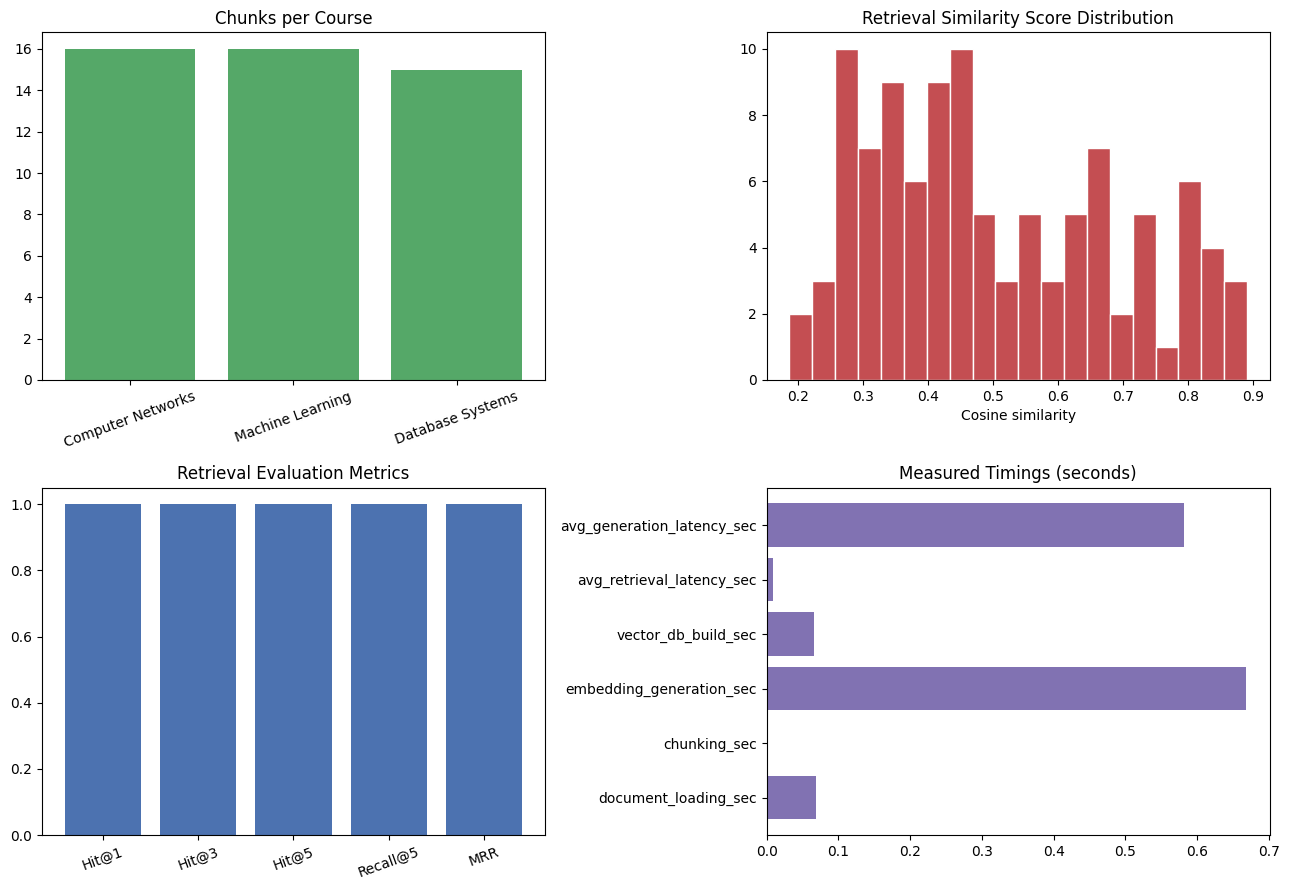

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

chunk_course_counts = pd.Series([c["metadata"]["course"] for c in chunks]).value_counts()
axes[0, 0].bar(chunk_course_counts.index, chunk_course_counts.values, color="#55A868")
axes[0, 0].set_title("Chunks per Course")
axes[0, 0].tick_params(axis="x", rotation=20)

axes[0, 1].hist(retrieval_similarities, bins=20, color="#C44E52", edgecolor="white")
axes[0, 1].set_title("Retrieval Similarity Score Distribution")
axes[0, 1].set_xlabel("Cosine similarity")

axes[1, 0].bar(list(retrieval_metrics.keys()), list(retrieval_metrics.values()), color="#4C72B0")
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title("Retrieval Evaluation Metrics")
axes[1, 0].tick_params(axis="x", rotation=20)

latency_keys = [k for k in PERF if "latency" in k or "_sec" in k]
axes[1, 1].barh(latency_keys, [PERF[k] for k in latency_keys], color="#8172B2")
axes[1, 1].set_title("Measured Timings (seconds)")

plt.tight_layout()
plt.show()

## 27. Persist Artifacts for `app.py`


In [27]:
app_config = dict(CONFIG)
app_config["DETECTED_COURSES"] = DETECTED_COURSES if not USING_DEMO_DATA else CONFIG["COURSES"]
app_config["USING_DEMO_DATA"] = USING_DEMO_DATA

with open(Path(CONFIG["OUTPUT_DIR"]) / "config.json", "w", encoding="utf-8") as f:
    json.dump(app_config, f, indent=2)

with open(Path(CONFIG["OUTPUT_DIR"]) / "evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump({
        "retrieval_metrics": retrieval_metrics,
        "answer_evaluation_summary": {
            "mean_relevance": float(answer_eval_df["Relevance"].mean()),
            "mean_groundedness": float(answer_eval_df["Groundedness"].mean()),
            "mean_completeness": float(answer_eval_df["Completeness"].mean()),
        },
        "hallucination_refusal_rate": refusal_rate,
        "performance": PERF,
    }, f, indent=2)

print("Saved:")
print(f"  {Path(CONFIG['OUTPUT_DIR']) / 'config.json'}")
print(f"  {Path(CONFIG['OUTPUT_DIR']) / 'evaluation_results.json'}")
print(f"  {CONFIG['VECTOR_DB_PATH']}/  (persistent Chroma vector database, {collection.count()} chunks)")

Saved:
  /kaggle/working/rag_outputs/config.json
  /kaggle/working/rag_outputs/evaluation_results.json
  /kaggle/working/vector_db/  (persistent Chroma vector database, 47 chunks)


## 28. Reproducibility Checklist

In [28]:
import sentence_transformers, chromadb as chromadb_pkg, transformers as transformers_pkg

checklist = {
    "Random seed": CONFIG["SEED"],
    "Dataset path": CONFIG["INPUT_DIR"] + (" (demo fallback used)" if USING_DEMO_DATA else ""),
    "Embedding model": CONFIG["EMBEDDING_MODEL"],
    "Chunk size / overlap": f"{CONFIG['CHUNK_SIZE']} / {CONFIG['CHUNK_OVERLAP']}",
    "Top-K": CONFIG["TOP_K"],
    "LLM backend": f"{CONFIG['LLM_BACKEND']} ({CONFIG['LOCAL_LLM_MODEL'] if CONFIG['LLM_BACKEND'] == 'local' else CONFIG['API_MODEL_NAME']})",
    "Hardware": f"{DEVICE.upper()}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""),
    "torch": torch.__version__,
    "sentence-transformers": sentence_transformers.__version__,
    "chromadb": chromadb_pkg.__version__,
    "transformers": transformers_pkg.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
}

for k, v in checklist.items():
    print(f"  {k}: {v}")

  Random seed: 42
  Dataset path: /kaggle/input (demo fallback used)
  Embedding model: sentence-transformers/all-MiniLM-L6-v2
  Chunk size / overlap: 500 / 100
  Top-K: 5
  LLM backend: local (google/flan-t5-base)
  Hardware: CUDA (Tesla T4)
  torch: 2.10.0+cu128
  sentence-transformers: 5.7.0
  chromadb: 1.5.9
  transformers: 5.0.0
  pandas: 2.3.3
  numpy: 2.0.2


## 29. Final Report

### Results

The measured numbers below are pulled directly from the variables computed in this run.

In [29]:
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Files ingested        : {len(dataset_df)} ({'demo dataset' if USING_DEMO_DATA else 'real course materials'})")
print(f"Documents extracted    : {len(raw_documents)}")
print(f"Chunks indexed         : {len(chunks)}")
print(f"Retrieval Hit@1/3/5    : {retrieval_metrics['Hit@1']:.2f} / {retrieval_metrics['Hit@3']:.2f} / {retrieval_metrics['Hit@5']:.2f}")
print(f"Retrieval MRR          : {retrieval_metrics['MRR']:.2f}")
print(f"Mean answer relevance  : {answer_eval_df['Relevance'].mean():.2f}")
print(f"Mean groundedness      : {answer_eval_df['Groundedness'].mean():.2f}")
print(f"Hallucination refusal  : {refusal_rate:.0%}")
print(f"Avg retrieval latency  : {PERF['avg_retrieval_latency_sec'] * 1000:.0f} ms")
print(f"Avg generation latency : {PERF['avg_generation_latency_sec']:.2f} s")

RESULTS SUMMARY
Files ingested        : 12 (demo dataset)
Documents extracted    : 27
Chunks indexed         : 47
Retrieval Hit@1/3/5    : 1.00 / 1.00 / 1.00
Retrieval MRR          : 1.00
Mean answer relevance  : 0.73
Mean groundedness      : 0.17
Hallucination refusal  : 0%
Avg retrieval latency  : 9 ms
Avg generation latency : 0.58 s
